In [210]:
import torch
import hippynn
import matplotlib.pyplot as plt
import matplotlib
import re
import numpy as np

plt.rcParams.update({
        'font.size': 10,
        'legend.fontsize': 10,
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'figure.figsize': (6, 4),
        'text.usetex': True,
        'errorbar.capsize': 6.0

    })
matplotlib.rcParams['figure.dpi'] = 300     # what you see in the notebook
plt.rc('font', family='serif') 

matplotlib.rcParams['xtick.labelsize'] = 10 
matplotlib.rcParams['ytick.labelsize'] = 10 
matplotlib.rcParams['font.size'] = 10

In [199]:
all_speed_data = torch.load('./a100_speed_eval.pt')
n_configs = speed_metrics = None
speed_metrics = all_speed_data.pop('metrics', speed_metrics)
n_configs = all_speed_data.pop('n_configs',n_configs)

/var/folders/01/5fs_12112d51__2md2crbk70000tpn/T/ipykernel_60578/1689018362.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_speed_data = torch.load('./a100_speed_eva

In [200]:
all_speed_data['device_name']

'NVIDIA A100-SXM4-40GB'

In [201]:
n_atoms_approx = 676000
n_configs_approx = 49000
n_atoms_per_config =n_atoms_approx/n_configs_approx
n_atoms_per_config
batch_size=1024
all_min = {}
for model,speeds in speed_metrics.items():
    model = dict(model)
    if model['batch_size']!=batch_size:
        continue
    model.pop('batch_size')
    min_speed = min(speeds)
    
    if model["tensor_model"]=="TS":
        model["tensor_factors"] = 2
    elif model["tensor_model"]=="NONE":
        model["tensor_factors"] = 1
        model['tensor_order'] = 0

    model = tuple(sorted(model.items(),key=lambda kv:kv[0]))
    all_min[model] = min_speed
    


In [202]:
all_min

{(('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 4.894317150115967,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 3.845236301422119,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 3.336777925491333,
 (('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 2.2065978050231934,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 2.1324758529663086,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 1.8633909225463867,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 1)): 0.9399440288543701,
 (('tensor_factors', 2),
  ('tensor_model', 'TS'),
  ('tensor_order', 1)): 0.9476072788238525,
 (('tensor_factors', 2),
  ('tensor_model', 'TS'),
  ('tensor_order', 2)): 1.8701286315917969,
 (('tensor_factors', 1),
  ('tensor_model', 'NONE'),
  ('tensor_order', 0)): 0.4787006378173828}

In [203]:
# metrics1 = torch.load('../ln_compare_metrics.pt',weights_only=False)
metrics1 = torch.load('../full_ln_results.pt',weights_only=False)
metrics3 = torch.load('../gn_compare_models/post_evaluation_metrics.pt',weights_only=False)
metrics2 = torch.load('../gn_compare_models/old_post_eval_metrics.pt',weights_only=False)
metrics = {**metrics2,**metrics1,**metrics3}
#metreics = {**metrics1,**metrics2}

In [204]:
from collections import defaultdict
distilled_metrics = {}
model_buckets = defaultdict(list)
for model_name, met in metrics.items():
    print(model_name)
    if "gnFalse" in model_name:
        continue
    met_dict = met.other_metric_values['final tests']['test']
    distilled_metrics[model_name]=met_dict
    matches = re.findall(r"gnTrue(?:_seed|(?:_l([0-9])_n([0-9]))|(?:_(TS|HOP|NONE)_l([0-9])_n([0-9])))", model_name)
    matches_orig = matches
    #print(matches)
    if len(matches)!=1:
        if "False" in model_name:
            continue
        else:
            print("WHAT MODEL:",model_name)
            continue

    print(matches)
    el1, en1, model, el2, en2= matches[0]
    
    if not model:
        model = "HOP"
        if el1:
            el = el1
            en = en1
        else:
            el = 3
            en = 4
    else:
        el=el2
        en=en2
        
    if model=="TS":
        en=2
    if model=="NONE":
        en=1
        el=0
    
#     model = model or "HOP"
    
#     if model == "NONE":
#         el = 0
#         en = 1
#     elif model =="TS":
#         en = 2
        
#     el = el or "3"
#     en = en or "4"
    
    el = int(el)
    en = int(en)

    print(model_name)
    print(model,el,en)
    
    key = (("tensor_model",model),("tensor_factors",en),("tensor_order",el))
    key = tuple(sorted(key,key=lambda kv:kv[0]))
    model_buckets[key].append(model_name)
    
    #print(met)
model_buckets = dict(model_buckets)

INTERACTIVE_gnFalse_seed439778_GPU0
INTERACTIVE_gnFalse_seed537332_GPU0
INTERACTIVE_gnTrue_seed24475_GPU0
[('', '', '', '', '')]
INTERACTIVE_gnTrue_seed24475_GPU0
HOP 3 4
INTERACTIVE_gnTrue_seed293423_GPU0
[('', '', '', '', '')]
INTERACTIVE_gnTrue_seed293423_GPU0
HOP 3 4
train_gn_compare.sh_gnFalse_seed125744_GPU0
train_gn_compare.sh_gnFalse_seed398067_GPU0
train_gn_compare.sh_gnFalse_seed504670_GPU0
train_gn_compare.sh_gnFalse_seed657366_GPU0
train_gn_compare.sh_gnTrue_seed163442_GPU0
[('', '', '', '', '')]
train_gn_compare.sh_gnTrue_seed163442_GPU0
HOP 3 4
train_gn_compare.sh_gnTrue_seed356132_GPU0
[('', '', '', '', '')]
train_gn_compare.sh_gnTrue_seed356132_GPU0
HOP 3 4
train_gn_compare.sh_gnTrue_seed53621_GPU0
[('', '', '', '', '')]
train_gn_compare.sh_gnTrue_seed53621_GPU0
HOP 3 4
train_gn_compare.sh_gnTrue_seed713474_GPU0
[('', '', '', '', '')]
train_gn_compare.sh_gnTrue_seed713474_GPU0
HOP 3 4
ln_compare-models_gnTrue_l2_n3_seed835955_GPU0
[('2', '3', '', '', '')]
ln_compare-mod

In [205]:
model_buckets.keys()

dict_keys([(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3)), (('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2)), (('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2)), (('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3)), (('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3)), (('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1)), (('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2)), (('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0)), (('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1)), (('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))])

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


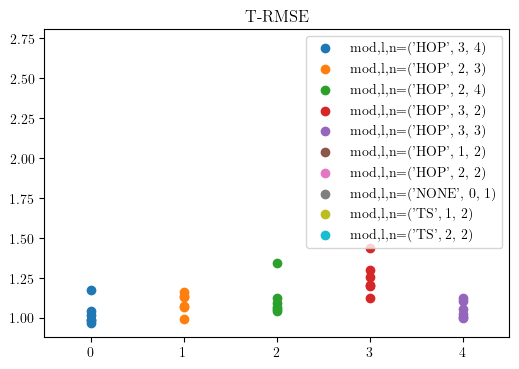

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


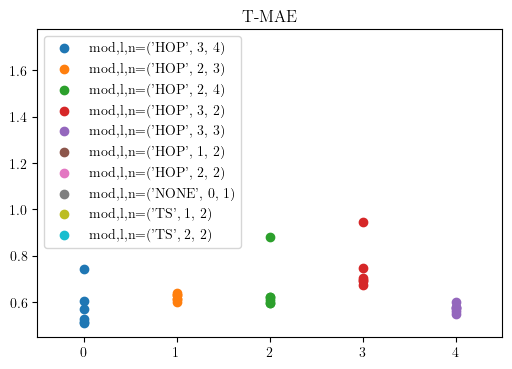

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


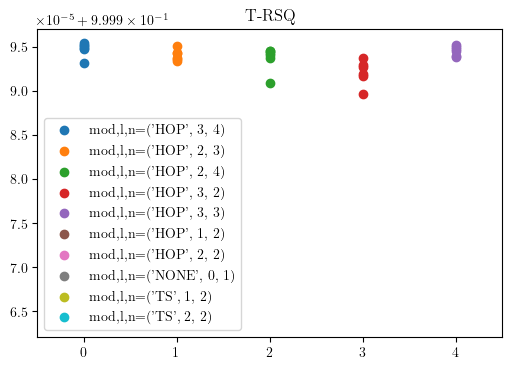

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


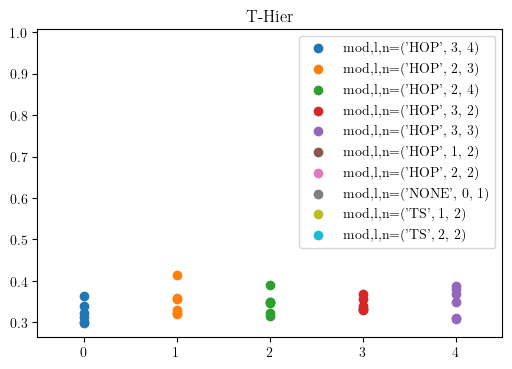

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


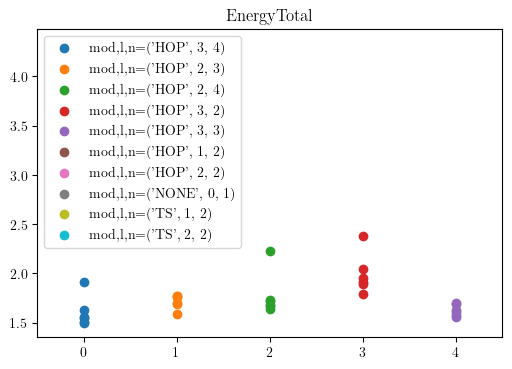

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


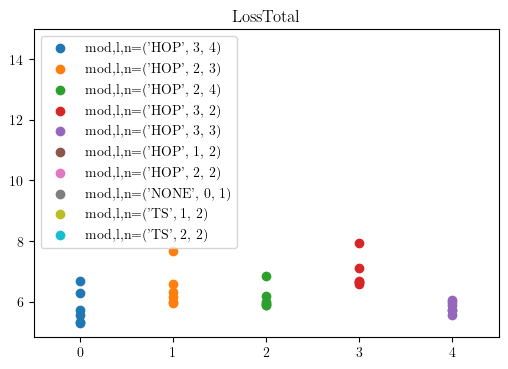

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


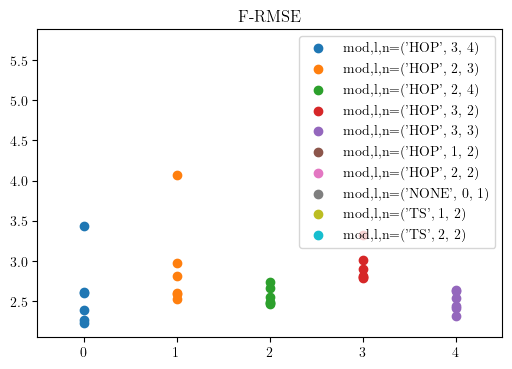

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


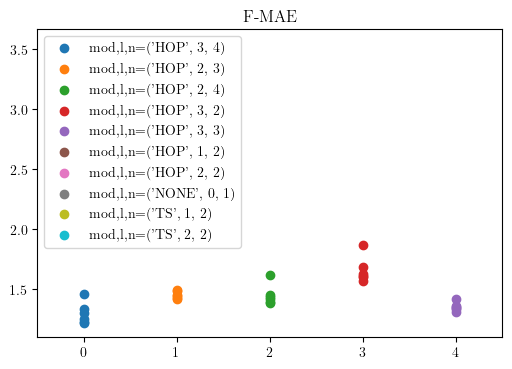

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


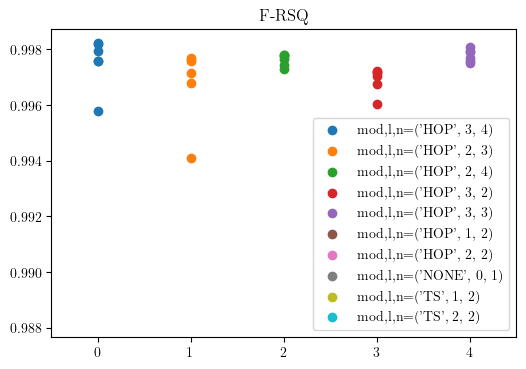

(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 4
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 3
(('tensor_factors', 4), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 4
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 2
(('tensor_factors', 3), ('tensor_model', 'HOP'), ('tensor_order', 3))
HOP 3 3
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 1))
HOP 1 2
(('tensor_factors', 2), ('tensor_model', 'HOP'), ('tensor_order', 2))
HOP 2 2
(('tensor_factors', 1), ('tensor_model', 'NONE'), ('tensor_order', 0))
NONE 0 1
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 1))
TS 1 2
(('tensor_factors', 2), ('tensor_model', 'TS'), ('tensor_order', 2))
TS 2 2


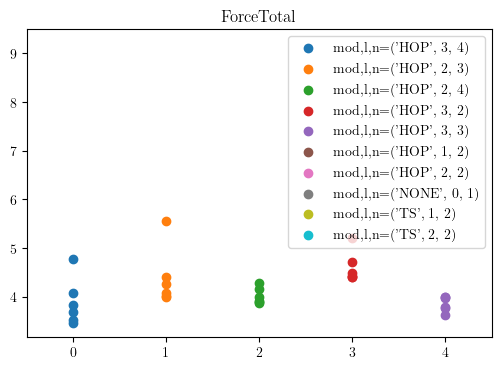

In [206]:
key_vals = met_dict.keys()
bucket_vals = model_buckets.keys()
for k in key_vals:
    
    for i,model in enumerate(model_buckets.keys()):
        model_d = dict(model)
        
        ell = model_d["tensor_order"]
        en = model_d['tensor_factors']
        mod = model_d['tensor_model']
        print(model)
        print(mod,ell,en)
        model_vals = [distilled_metrics[name][k] for name in model_buckets[model]]
        x_vals = [i]*len(model_vals)
        plt.scatter(x_vals,model_vals,label=f"mod,l,n={mod,ell,en}")
    plt.legend()
    plt.xlim(-0.5,4.5)
    plt.title(k)
    plt.show()


{'tensor_factors': 4, 'tensor_model': 'HOP', 'tensor_order': 3}
HOP 4 3 7.240114127390483
{'tensor_factors': 3, 'tensor_model': 'HOP', 'tensor_order': 2}
HOP 3 2 3.1545500783525275
{'tensor_factors': 4, 'tensor_model': 'HOP', 'tensor_order': 2}
HOP 4 2 3.2641979364248424
{'tensor_factors': 2, 'tensor_model': 'HOP', 'tensor_order': 3}
HOP 2 3 4.9360620199575935
{'tensor_factors': 3, 'tensor_model': 'HOP', 'tensor_order': 3}
HOP 3 3 5.688219380801952
{'tensor_factors': 2, 'tensor_model': 'HOP', 'tensor_order': 1}
HOP 2 1 1.3904497468259913
{'tensor_factors': 2, 'tensor_model': 'HOP', 'tensor_order': 2}
HOP 2 2 2.7564954475538266
{'tensor_factors': 1, 'tensor_model': 'NONE', 'tensor_order': 0}
NONE 1 0 0.7081370381913946
{'tensor_factors': 2, 'tensor_model': 'TS', 'tensor_order': 1}
TS 2 1 1.4017859154199002
{'tensor_factors': 2, 'tensor_model': 'TS', 'tensor_order': 2}
TS 2 2 2.76646247276893
['Original ($\\ell=0$)', 'TS ($\\ell=1$)', 'TS ($\\ell=2$)', 'HOP ($\\ell=1$)', 'HOP ($\\ell=2$)

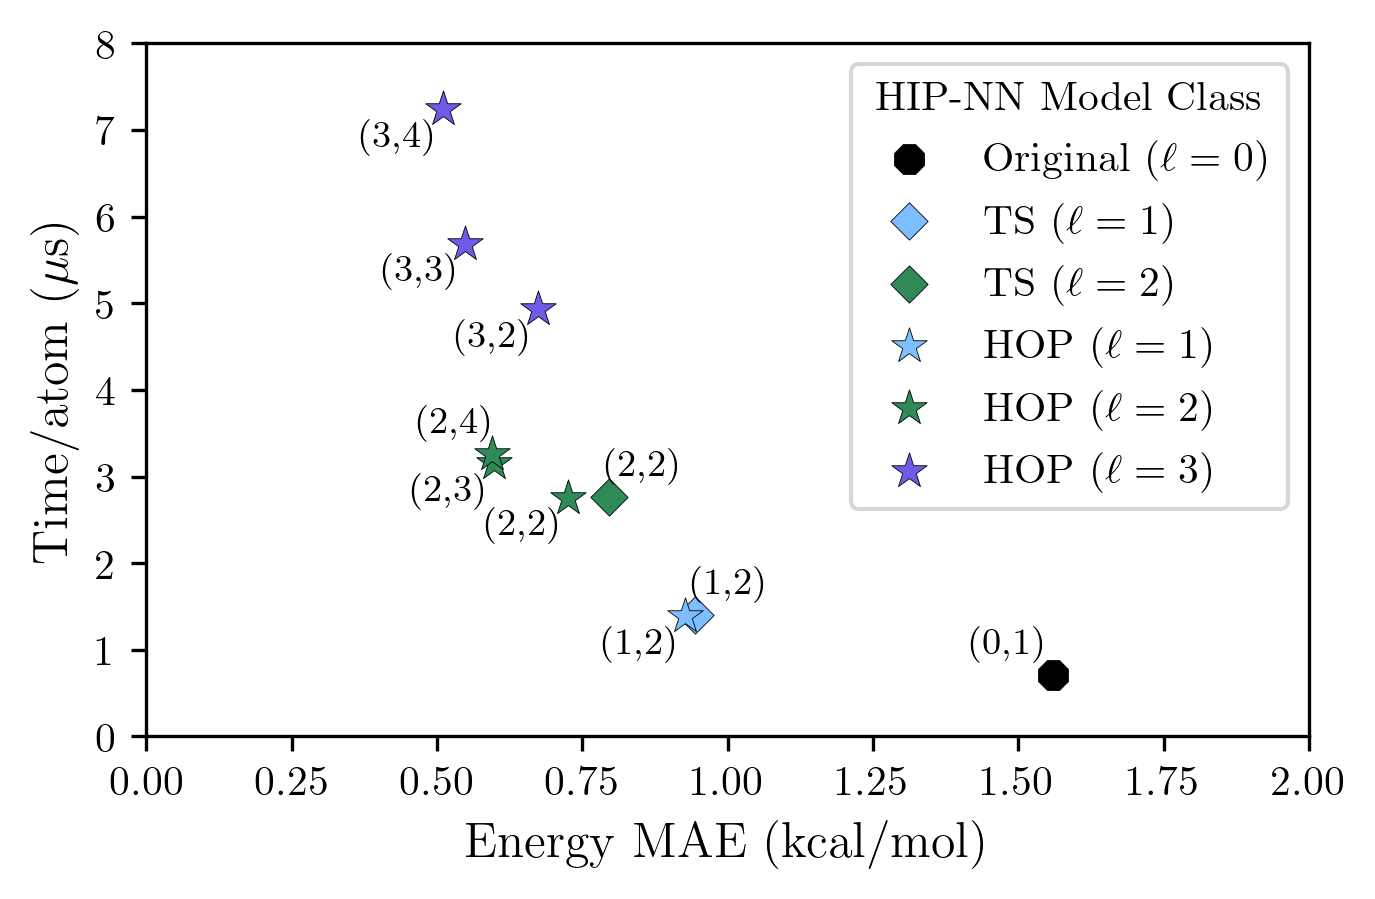

In [220]:
k = "T-MAE"
marker_style = {
    "HOP":("*",2),
    "TS":("D",1),
    "NONE":("8",1.5),
}
marker_scale = 40
display_name = {
    "HOP":"HOP",
    "TS":"TS",
    "NONE":"Original",

}
zorder = {
    "HOP":1,
    "TS":0,
    "NONE":-1,

}

from collections import defaultdict
text_offsets=defaultdict(lambda: (-1,-2))

#text_offsets["HOP",3,4] = (21,-1)
text_offsets["HOP",2,4] = (1,12)
text_offsets["TS",2,2] = (18,12)
text_offsets["TS",1,2] = (18,12)
text_offsets["NONE",0,1] = (-1,12)


marker_color = {
    0:"k",
    1:"xkcd:light blue",
    2:"xkcd:green",
    3:"xkcd:dark periwinkle",
}

marker_color = {
    0:"k",
    1:"#7DBEFF",
    2:"#2E8B57",
    3:"#6C5CE7",
}


fig,ax = plt.subplots(figsize=(5,3))
all_labels = []
for i,model in enumerate(model_buckets.keys()):
    model_d = dict(model)

    ell = model_d["tensor_order"]
    en = model_d['tensor_factors']
    mod = model_d['tensor_model']
    model_vals = [distilled_metrics[name][k] for name in model_buckets[model]]
    min_loss = min(model_vals)
    speed = all_min[model]
    color = marker_color[ell]
    style,size = marker_style[mod]
    size = marker_scale*size
    all_labels.append(model_d)
    print(model_d)
    if mod != "NONE":
        label=f"{display_name[mod]}, $\ell={ell}$"
    else:
        label = f"{display_name[mod]}"
    #lmax = r"$\ell_\textrm{max}"
    lmax = r"$\ell"
    label=f"{display_name[mod]} ("+lmax +f"={ell}$)"
    
    # convert speed in seconds to speed per atom (microseconds)
    time_per_atom = (speed/n_atoms_approx) * 1e6
    print(mod,en,ell,time_per_atom)

    plt.scatter(min_loss,time_per_atom,marker=style,edgecolor='k',linewidths=0.2,s=size,c=color,label=label,zorder=zorder[mod])
    annotation = f"({ell},{en})"
    xytext = text_offsets[mod,ell,en]
    plt.annotate(annotation, (min_loss, time_per_atom), xytext=xytext, textcoords='offset points',
                ha='right', va='top', fontsize=9)
    
    #plt.scatter(x_vals,model_vals,label=f"l,n={ell,en}")
    
# Get automatically generated handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

unique_labels, label_indices = np.unique(labels,return_index=True)
unique_handles = [handles[i] for i in label_indices]
unique_all_labels = [all_labels[i] for i in label_indices]

model_order = list(reversed(["NONE","TS","HOP"]))
key_func = lambda d: -(10*model_order.index(d["tensor_model"]) - d["tensor_order"])

new_order = list(sorted(range(len(unique_labels)), key=lambda i: key_func(unique_all_labels[i])))
ordered_handles = [unique_handles[i] for i in new_order]
ordered_labels  = [unique_labels[i]  for i in new_order]


# Reorder handles and labels accordingly
print(ordered_labels)
# Create legend with the reordered entries
plt.legend(ordered_handles, ordered_labels, title="HIP-NN Model Class")
plt.xlabel("Energy MAE (kcal/mol)")
plt.ylabel("Time/atom ($\\mu$s)")
#plt.yscale('log')
#plt.ylim(0.8,12)
plt.xlim(0,2)
plt.ylim(0,8)
#plt.title("Throughput-Accuracy Tradeoff")
plt.savefig("pareto_plot.pdf",bbox_inches='tight')
plt.show()

{'tensor_factors': 4, 'tensor_model': 'HOP', 'tensor_order': 3}
{'tensor_factors': 3, 'tensor_model': 'HOP', 'tensor_order': 2}
{'tensor_factors': 4, 'tensor_model': 'HOP', 'tensor_order': 2}
{'tensor_factors': 2, 'tensor_model': 'HOP', 'tensor_order': 3}
{'tensor_factors': 3, 'tensor_model': 'HOP', 'tensor_order': 3}
{'tensor_factors': 2, 'tensor_model': 'HOP', 'tensor_order': 1}
{'tensor_factors': 2, 'tensor_model': 'HOP', 'tensor_order': 2}
{'tensor_factors': 1, 'tensor_model': 'NONE', 'tensor_order': 0}
{'tensor_factors': 2, 'tensor_model': 'TS', 'tensor_order': 1}
{'tensor_factors': 2, 'tensor_model': 'TS', 'tensor_order': 2}
['Original ($\\ell$=0)', 'TS ($\\ell$=1)', 'TS ($\\ell$=2)', 'HOP ($\\ell$=1)', 'HOP ($\\ell$=2)', 'HOP ($\\ell$=3)']


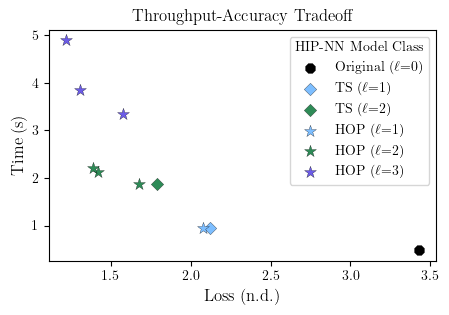

In [208]:
k = ""
marker_style = {
    "HOP":("*",2),
    "TS":("D",1),
    "NONE":("8",1.5),
}
marker_scale = 40
display_name = {
    "HOP":"HOP",
    "TS":"TS",
    "NONE":"Original",

}
zorder = {
    "HOP":1,
    "TS":0,
    "NONE":-1,

}

marker_color = {
    0:"k",
    1:"xkcd:light blue",
    2:"xkcd:green",
    3:"xkcd:dark periwinkle",
}

marker_color = {
    0:"k",
    1:"#7DBEFF",
    2:"#2E8B57",
    3:"#6C5CE7",
}


fig,ax = plt.subplots(figsize=(5,3))
all_labels = []
for i,model in enumerate(model_buckets.keys()):
    model_d = dict(model)

    ell = model_d["tensor_order"]
    en = model_d['tensor_factors']
    mod = model_d['tensor_model']
    model_vals = [distilled_metrics[name][k] for name in model_buckets[model]]
    min_loss = min(model_vals)
    speed = all_min[model]
    color = marker_color[ell]
    style,size = marker_style[mod]
    size = marker_scale*size
    all_labels.append(model_d)
    print(model_d)
    if mod != "NONE":
        label=f"{display_name[mod]}, $\ell$={ell}"
    else:
        label = f"{display_name[mod]}"
    label=f"{display_name[mod]} ($\ell$={ell})"
    plt.scatter(min_loss,speed,marker=style,edgecolor='k',linewidths=0.2,s=size,c=color,label=label,zorder=zorder[mod])
    
    #plt.scatter(x_vals,model_vals,label=f"l,n={ell,en}")
    
# Get automatically generated handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

unique_labels, label_indices = np.unique(labels,return_index=True)
unique_handles = [handles[i] for i in label_indices]
unique_all_labels = [all_labels[i] for i in label_indices]

model_order = list(reversed(["NONE","TS","HOP"]))
key_func = lambda d: -(10*model_order.index(d["tensor_model"]) - d["tensor_order"])

new_order = list(sorted(range(len(unique_labels)), key=lambda i: key_func(unique_all_labels[i])))
ordered_handles = [unique_handles[i] for i in new_order]
ordered_labels  = [unique_labels[i]  for i in new_order]


# Reorder handles and labels accordingly
print(ordered_labels)
# Create legend with the reordered entries
plt.legend(ordered_handles, ordered_labels, title="HIP-NN Model Class")
plt.xlabel("Loss (n.d.)")
plt.ylabel("Time (s)")
#plt.yscale('log')
plt.title("Throughput-Accuracy Tradeoff")
plt.show()

In [120]:
n_configs

48957

In [53]:
all_min

{(('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 7.223468542098999,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 5.808273077011108,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 5.114732503890991,
 (('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 3.1953134536743164,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 3.097709894180298,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 2.7365059852600098,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 1)): 1.3311643600463867,
 (('tensor_factors', 2),
  ('tensor_model', 'TS'),
  ('tensor_order', 1)): 1.3881535530090332,
 (('tensor_factors', 2),
  ('tensor_model', 'TS'),
  ('tensor_order', 2)): 2.8214213848114014,
 (('tensor_factors', 1),
  ('tensor_model', 'NONE'),
  ('tensor_order', 0)): 0.6221792697906494}

In [14]:
model_buckets

{(('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order',
   3)): ['INTERACTIVE_gnTrue_seed24475_GPU0', 'INTERACTIVE_gnTrue_seed293423_GPU0', 'train_gn_compare.sh_gnTrue_seed163442_GPU0', 'train_gn_compare.sh_gnTrue_seed356132_GPU0', 'train_gn_compare.sh_gnTrue_seed53621_GPU0', 'train_gn_compare.sh_gnTrue_seed713474_GPU0'],
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order',
   2)): ['ln_compare-models_gnTrue_l2_n3_seed835955_GPU0', 'ln_compare_models_gnTrue_l2_n3_seed241497_GPU0', 'ln_compare_models_gnTrue_l2_n3_seed332725_GPU0', 'ln_compare_models_gnTrue_l2_n3_seed482074_GPU0', 'ln_compare_models_gnTrue_l2_n3_seed503248_GPU0', 'ln_compare_models_gnTrue_l2_n3_seed679176_GPU0'],
 (('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order',
   2)): ['ln_compare-models_gnTrue_l2_n4_seed814096_GPU0', 'ln_compare_models_gnTrue_l2_n4_seed36698_GPU0', 'ln_compare_models_gnTrue_l2_n4_seed402867_GPU0', 'ln_compare_models_gnTrue_l2_n4_seed536117_GPU0', '

In [ ]:
for model, 

In [5]:
all_min

{(('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 7.47615385055542,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 6.001024961471558,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 5.3000757694244385,
 (('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 3.395747184753418,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 3.2939183712005615,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 2.9379260540008545,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 1)): 1.620375394821167,
 (('tensor_factors', 0),
  ('tensor_model', 'TS'),
  ('tensor_order', 1)): 1.6128528118133545,
 (('tensor_factors', 0),
  ('tensor_model', 'TS'),
  ('tensor_order', 2)): 3.0522167682647705,
 (('tensor_factors', 0),
  ('tensor_model', 'NONE'),
  ('tensor_order', 0)): 1.0542261600494385}

In [33]:
all_min

{(('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 7.223468542098999,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 5.808273077011108,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 3)): 5.114732503890991,
 (('tensor_factors', 4),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 3.1953134536743164,
 (('tensor_factors', 3),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 3.097709894180298,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 2)): 2.7365059852600098,
 (('tensor_factors', 2),
  ('tensor_model', 'HOP'),
  ('tensor_order', 1)): 1.3311643600463867,
 (('tensor_factors', 0),
  ('tensor_model', 'TS'),
  ('tensor_order', 1)): 1.3881535530090332,
 (('tensor_factors', 0),
  ('tensor_model', 'TS'),
  ('tensor_order', 2)): 2.8214213848114014,
 (('tensor_factors', 0),
  ('tensor_model', 'NONE'),
  ('tensor_order', 0)): 0.6221792697906494}

In [6]:
metrics

NameError: name 'metrics' is not defined

In [139]:
n_atoms_approx = 676000
n_configs_approx = 49000
n_atoms_per_config =n_atoms_approx/n_configs_approx
n_atoms_per_config

13.795918367346939

In [ ]:
atoms_per_config=tensor(13.8161, device='cuda:0')n_atoms=tensor(676395, device='cuda:0')n_configs=48957
atoms_per_config=tensor(13.8101, device='cuda:0')n_atoms=tensor(676103, device='cuda:0')n_configs=48957
atoms_per_config=tensor(13.7921, device='cuda:0')n_atoms=tensor(675222, device='cuda:0')n_configs=48957
atoms_per_config=tensor(13.7911, device='cuda:0')n_atoms=tensor(675171, device='cuda:0')n_configs=48957
atoms_per_config=tensor(13.8394, device='cuda:0')n_atoms=tensor(677535, device='cuda:0')n_configs=48957
atoms_per_config=tensor(13.7845, device='cuda:0')n_atoms=tensor(674847, device='cuda:0')n_configs=48957
